<a href="https://colab.research.google.com/github/duncanian303-cloud/f1-strategy-ml/blob/main/notebooks/f1_strategy.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd

# Load the dataset
file_path = '/content/f1_strategy_dataset_v4.csv'
df = pd.read_csv(file_path)

# Display the first few rows to inspect the data
display(df.head())

,Driver,LapNumber,Compound,Stint,TyreLife,Position,LapTime (s),Race,Year,LapTime_Delta,Cumulative_Degradation,PitStop,PitNextLap,RaceProgress,Normalized_TyreLife,Position_Change
0,ALB,1,MEDIUM,1,2.0,17,100.625,Abu Dhabi Grand Prix,2023,0.000,0.000,0,0,0.017241,0.117647,0.0
1,ALB,2,MEDIUM,1,3.0,18,93.560,Abu Dhabi Grand Prix,2023,-7.065,-7.065,0,0,0.034483,0.176471,-1.0
2,ALB,3,MEDIUM,1,4.0,18,91.768,Abu Dhabi Grand Prix,2023,-1.792,-8.857,0,0,0.051724,0.235294,0.0
3,ALB,4,MEDIUM,1,5.0,18,91.591,Abu Dhabi Grand Prix,2023,-0.177,-9.034,0,0,0.068966,0.294118,0.0
4,ALB,5,MEDIUM,1,6.0,18,91.422,Abu Dhabi Grand Prix,2023,-0.169,-9.203,0,0,0.086207,0.352941,0.0


In [2]:
missing_values = df.isnull().sum()
print("Missing values per column:")
display(missing_values[missing_values > 0] if missing_values.any() else "No missing values found.")

Missing values per column:


,0
Compound,66


In [3]:
# Drop rows where 'Compound' is missing
df = df.dropna(subset=['Compound'])

# Verify that there are no more missing values
print(f"Missing values in Compound after cleaning: {df['Compound'].isnull().sum()}")
print(f"Remaining rows in dataset: {len(df)}")

Missing values in Compound after cleaning: 0
Remaining rows in dataset: 101305


In [4]:
# Show data types of each column
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 101305 entries, 0 to 101370
Data columns (total 16 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   Driver                  101305 non-null  object 
 1   LapNumber               101305 non-null  int64  
 2   Compound                101305 non-null  object 
 3   Stint                   101305 non-null  int64  
 4   TyreLife                101305 non-null  float64
 5   Position                101305 non-null  int64  
 6   LapTime (s)             101305 non-null  float64
 7   Race                    101305 non-null  object 
 8   Year                    101305 non-null  int64  
 9   LapTime_Delta           101305 non-null  float64
 10  Cumulative_Degradation  101305 non-null  float64
 11  PitStop                 101305 non-null  int64  
 12  PitNextLap              101305 non-null  int64  
 13  RaceProgress            101305 non-null  float64
 14  Normalized_TyreLife     1

In [5]:
# Calculate summary statistics for numerical columns
summary_stats = df.describe()
display(summary_stats)

,LapNumber,Stint,TyreLife,Position,LapTime (s),Year,LapTime_Delta,Cumulative_Degradation,PitStop,PitNextLap,RaceProgress,Normalized_TyreLife,Position_Change
count,101305.000000,101305.000000,101305.000000,101305.000000,101305.000000,101305.000000,101305.000000,101305.000000,101305.000000,101305.000000,101305.000000,101305.000000,101305.000000
mean,30.431302,2.045082,14.544712,9.758788,92.597575,2023.590721,-0.197137,-29.528322,0.251686,0.254588,0.432437,0.386400,-0.003721
std,18.143087,0.947369,10.312058,5.407104,33.239256,1.098126,45.356813,70.244867,0.433984,0.435631,0.258088,0.259865,3.913402
min,1.000000,1.000000,1.000000,1.000000,67.012000,2022.000000,-2403.895000,-274.564000,0.000000,0.000000,0.012821,0.012821,-18.000000
25%,15.000000,1.000000,7.000000,5.000000,82.031000,2023.000000,-7.246000,-51.027000,0.000000,0.000000,0.210526,0.172414,-2.000000
50%,30.000000,2.000000,13.000000,10.000000,91.181000,2024.000000,-0.026000,-21.663000,0.000000,0.000000,0.421053,0.333333,0.000000
75%,45.000000,3.000000,20.000000,14.000000,99.362000,2025.000000,5.721000,-3.716000,1.000000,1.000000,0.631579,0.562500,2.000000
max,78.000000,8.000000,78.000000,20.000000,2526.253000,2025.000000,2433.472000,2412.431000,1.000000,1.000000,1.000000,1.000000,18.000000


In [6]:
# Calculate mean LapTime grouped by Compound
mean_laptime_by_compound = df.groupby('Compound')['LapTime (s)'].mean().sort_values()

print("Average Lap Time (s) per Compound:")
display(mean_laptime_by_compound)

Average Lap Time (s) per Compound:


,LapTime (s)
Compound,
HARD,91.870211
SOFT,92.030626
MEDIUM,92.114455
INTERMEDIATE,102.019402
WET,107.056351


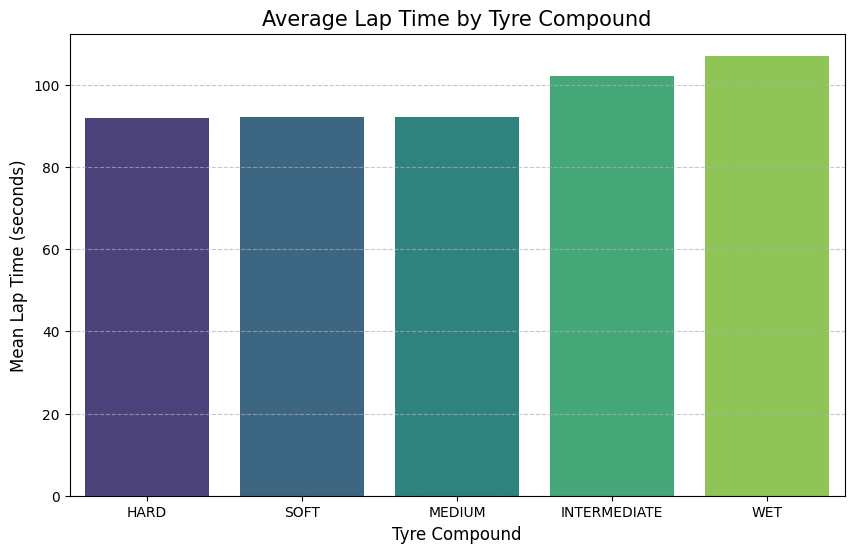

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# Reset index to convert Series to DataFrame for easier plotting
plot_df = mean_laptime_by_compound.reset_index()

# Create the bar chart
plt.figure(figsize=(10, 6))
sns.barplot(x='Compound', y='LapTime (s)', data=plot_df, hue='Compound', palette='viridis', legend=False)

# Add titles and labels
plt.title('Average Lap Time by Tyre Compound', fontsize=15)
plt.xlabel('Tyre Compound', fontsize=12)
plt.ylabel('Mean Lap Time (seconds)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Display the plot
plt.show()

In [9]:
# Select only numerical columns and calculate the correlation matrix
correlation_matrix = df.select_dtypes(include=['number']).corr()

# Display the correlation matrix
print("Correlation Matrix for Numerical Columns:")
display(correlation_matrix)

Correlation Matrix for Numerical Columns:


,LapNumber,Stint,TyreLife,Position,LapTime (s),Year,LapTime_Delta,Cumulative_Degradation,PitStop,PitNextLap,RaceProgress,Normalized_TyreLife,Position_Change
LapNumber,1.000000,0.651196,0.507038,-0.058120,-0.120267,0.033886,0.003414,-0.198075,0.157278,0.158924,0.964588,0.465778,0.002888
Stint,0.651196,1.000000,-0.021230,0.099084,-0.051791,-0.080813,-0.004259,-0.104004,0.109328,0.086808,0.647152,0.124858,0.000676
TyreLife,0.507038,-0.021230,1.000000,-0.138062,-0.108993,0.061826,0.003646,-0.086122,-0.209141,0.266077,0.488068,0.775098,0.052916
Position,-0.058120,0.099084,-0.138062,1.000000,0.024000,0.011813,-0.005922,0.011659,0.052845,-0.031795,-0.038726,-0.140604,-0.361090
LapTime (s),-0.120267,-0.051791,-0.108993,0.024000,1.000000,-0.035404,0.680288,0.460765,0.005493,-0.009778,-0.101528,-0.087226,0.002229
Year,0.033886,-0.080813,0.061826,0.011813,-0.035404,1.000000,-0.000520,-0.081181,0.103429,0.097576,-0.051709,-0.100529,0.001770
LapTime_Delta,0.003414,-0.004259,0.003646,-0.005922,0.680288,-0.000520,1.000000,0.323225,0.007237,0.003821,0.002798,0.007000,0.009595
Cumulative_Degradation,-0.198075,-0.104004,-0.086122,0.011659,0.460765,-0.081181,0.323225,1.000000,-0.117615,-0.121763,-0.166070,-0.046903,0.001644
PitStop,0.157278,0.109328,-0.209141,0.052845,0.005493,0.103429,0.007237,-0.117615,1.000000,-0.004763,0.096763,-0.323396,-0.115520
PitNextLap,0.158924,0.086808,0.266077,-0.031795,-0.009778,0.097576,0.003821,-0.121763,-0.004763,1.000000,0.098486,0.125011,0.057955


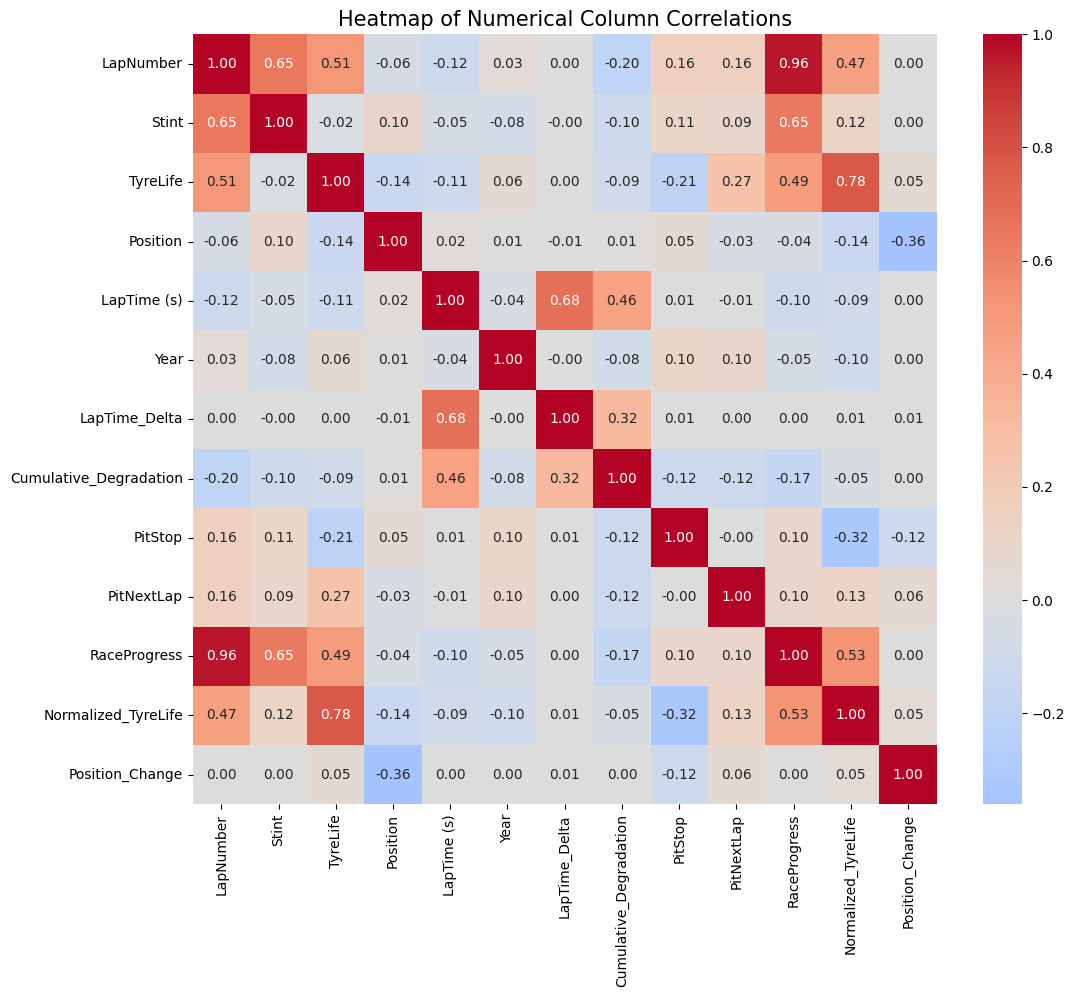

In [10]:
# Visualize the correlation matrix using a heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Heatmap of Numerical Column Correlations', fontsize=15)
plt.show()

In [25]:
# Revert: Reload the dataset to restore 'Race' and 'Year' columns
import pandas as pd
df = pd.read_csv('/content/f1_strategy_dataset_v4.csv')

# Drop only 'Year' if you still want to exclude it, but keep 'Race'
df = df.drop(columns=['Year'], errors='ignore')
df = df.dropna(subset=['Compound'])

print("Columns restored:")
print(df.columns.tolist())
display(df.head())

Columns restored:
['Driver', 'LapNumber', 'Compound', 'Stint', 'TyreLife', 'Position', 'LapTime (s)', 'Race', 'LapTime_Delta', 'Cumulative_Degradation', 'PitStop', 'PitNextLap', 'RaceProgress', 'Normalized_TyreLife', 'Position_Change']


,Driver,LapNumber,Compound,Stint,TyreLife,Position,LapTime (s),Race,LapTime_Delta,Cumulative_Degradation,PitStop,PitNextLap,RaceProgress,Normalized_TyreLife,Position_Change
0,ALB,1,MEDIUM,1,2.0,17,100.625,Abu Dhabi Grand Prix,0.000,0.000,0,0,0.017241,0.117647,0.0
1,ALB,2,MEDIUM,1,3.0,18,93.560,Abu Dhabi Grand Prix,-7.065,-7.065,0,0,0.034483,0.176471,-1.0
2,ALB,3,MEDIUM,1,4.0,18,91.768,Abu Dhabi Grand Prix,-1.792,-8.857,0,0,0.051724,0.235294,0.0
3,ALB,4,MEDIUM,1,5.0,18,91.591,Abu Dhabi Grand Prix,-0.177,-9.034,0,0,0.068966,0.294118,0.0
4,ALB,5,MEDIUM,1,6.0,18,91.422,Abu Dhabi Grand Prix,-0.169,-9.203,0,0,0.086207,0.352941,0.0


### Analyzing the Impact of Pit Stops
First, let's look at the average lap time for laps where a pit stop occurred versus standard laps.

In [12]:
# Group by PitStop to see the difference in average LapTime
pit_stop_impact = df.groupby('PitStop')['LapTime (s)'].mean().reset_index()
pit_stop_impact['PitStop'] = pit_stop_impact['PitStop'].map({0: 'Standard Lap', 1: 'Pit Stop Lap'})

display(pit_stop_impact)

,PitStop,LapTime (s)
0,Standard Lap,92.491681
1,Pit Stop Lap,92.912420


To visualize this better, let's plot the lap times over the course of a single race for one driver. This will clearly show the 'spikes' in time when a pit stop happens.

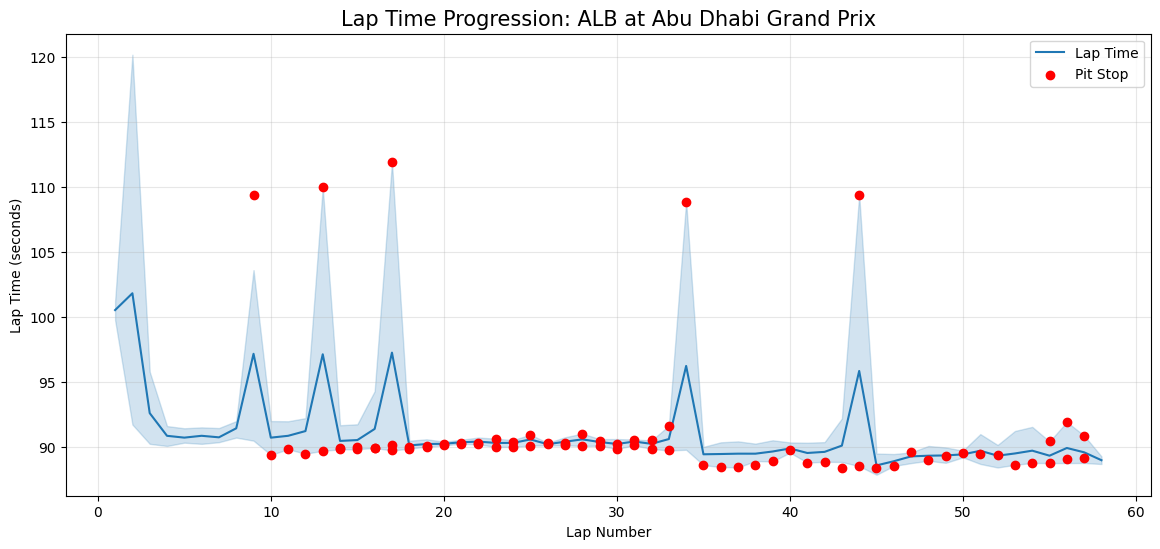

In [26]:
# Select a sample driver and race for visualization now that 'Race' is back
sample_driver = df['Driver'].unique()[0]
sample_race = df[df['Driver'] == sample_driver]['Race'].unique()[0]

driver_race_data = df[(df['Driver'] == sample_driver) & (df['Race'] == sample_race)]

plt.figure(figsize=(14, 6))
sns.lineplot(x='LapNumber', y='LapTime (s)', data=driver_race_data, label='Lap Time')

# Highlight pit stops
pit_stops = driver_race_data[driver_race_data['PitStop'] == 1]
plt.scatter(pit_stops['LapNumber'], pit_stops['LapTime (s)'], color='red', label='Pit Stop', zorder=5)

plt.title(f'Lap Time Progression: {sample_driver} at {sample_race}', fontsize=15)
plt.xlabel('Lap Number')
plt.ylabel('Lap Time (seconds)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### Driver and Race Performance Analysis
Let's calculate the performance metrics (Fastest Lap and Mean Lap Time) for every driver.

In [14]:
# Group by Driver to find performance metrics
driver_performance = df.groupby('Driver')['LapTime (s)'].agg(['min', 'mean', 'std']).reset_index()
driver_performance.columns = ['Driver', 'Fastest Lap', 'Average Lap', 'Std Dev']
driver_performance = driver_performance.sort_values(by='Fastest Lap')

print("Top 10 Drivers by Fastest Lap Time:")
display(driver_performance.head(10))

Top 10 Drivers by Fastest Lap Time:


,Driver,Fastest Lap,Average Lap,Std Dev
28,VER,67.012,91.738995,35.385620
15,LEC,67.583,92.084130,35.732664
1,ALO,67.694,92.685369,36.639382
21,PIA,67.924,90.691391,39.220923
18,NOR,68.016,92.036964,35.241780
20,PER,68.111,92.690261,13.815286
26,STR,68.463,92.751239,37.012012
11,HAM,68.628,92.062993,35.862554
24,SAI,68.880,91.544446,36.639696
9,GAS,69.046,93.197021,36.764847


Now, let's visualize the distribution of lap times across the top 5 most common races in the dataset to see how they differ.

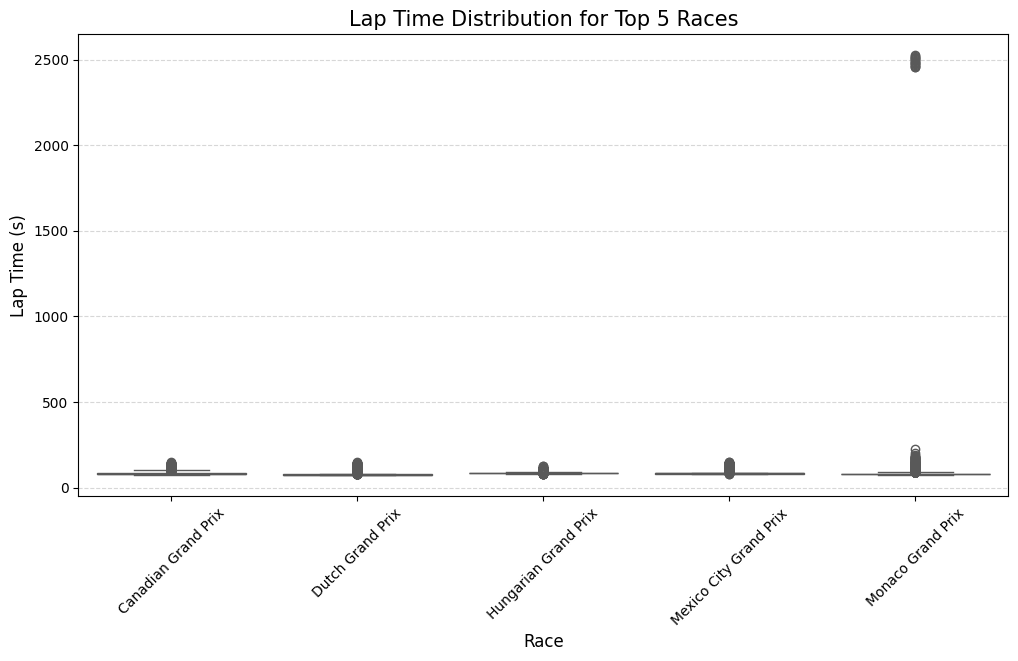

In [27]:
# Identify the top 5 races by number of entries
top_races = df['Race'].value_counts().nlargest(5).index.tolist()

# Filter data for these races
race_subset = df[df['Race'].isin(top_races)]

# Plot lap time distribution per race
plt.figure(figsize=(12, 6))
sns.boxplot(x='Race', y='LapTime (s)', data=race_subset, hue='Race', palette='Set2', legend=False)

plt.title('Lap Time Distribution for Top 5 Races', fontsize=15)
plt.xlabel('Race', fontsize=12)
plt.ylabel('Lap Time (s)', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

### Outlier and Skewness Analysis
In this section, we analyze the numerical features to understand their distribution symmetry and identify any potential outliers that might influence predictive modeling.

In [28]:
import numpy as np

# Calculate skewness for all numerical columns
numerical_cols = df.select_dtypes(include=['number']).columns
skewness = df[numerical_cols].skew().sort_values(ascending=False)

print("Skewness of Numerical Columns (Positive = Right Skew, Negative = Left Skew):")
display(skewness.to_frame(name='Skewness'))

Skewness of Numerical Columns (Positive = Right Skew, Negative = Left Skew):


,Skewness
LapTime (s),59.417063
Cumulative_Degradation,5.917844
PitStop,1.144372
TyreLife,1.137387
PitNextLap,1.126720
Stint,0.919996
LapTime_Delta,0.730409
Normalized_TyreLife,0.603872
LapNumber,0.216037
RaceProgress,0.214640


In [29]:
def detect_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    return outliers, lower_bound, upper_bound

# Analyze outliers for LapTime (s)
laptime_outliers, lb, ub = detect_outliers_iqr(df, 'LapTime (s)')
print(f"Outlier detection for LapTime (s):")
print(f"Bounds: [{lb:.2f}, {ub:.2f}]")
print(f"Number of outliers: {len(laptime_outliers)} ({len(laptime_outliers)/len(df)*100:.2f}% of data)")

Outlier detection for LapTime (s):
Bounds: [56.03, 125.36]
Number of outliers: 2926 (2.89% of data)


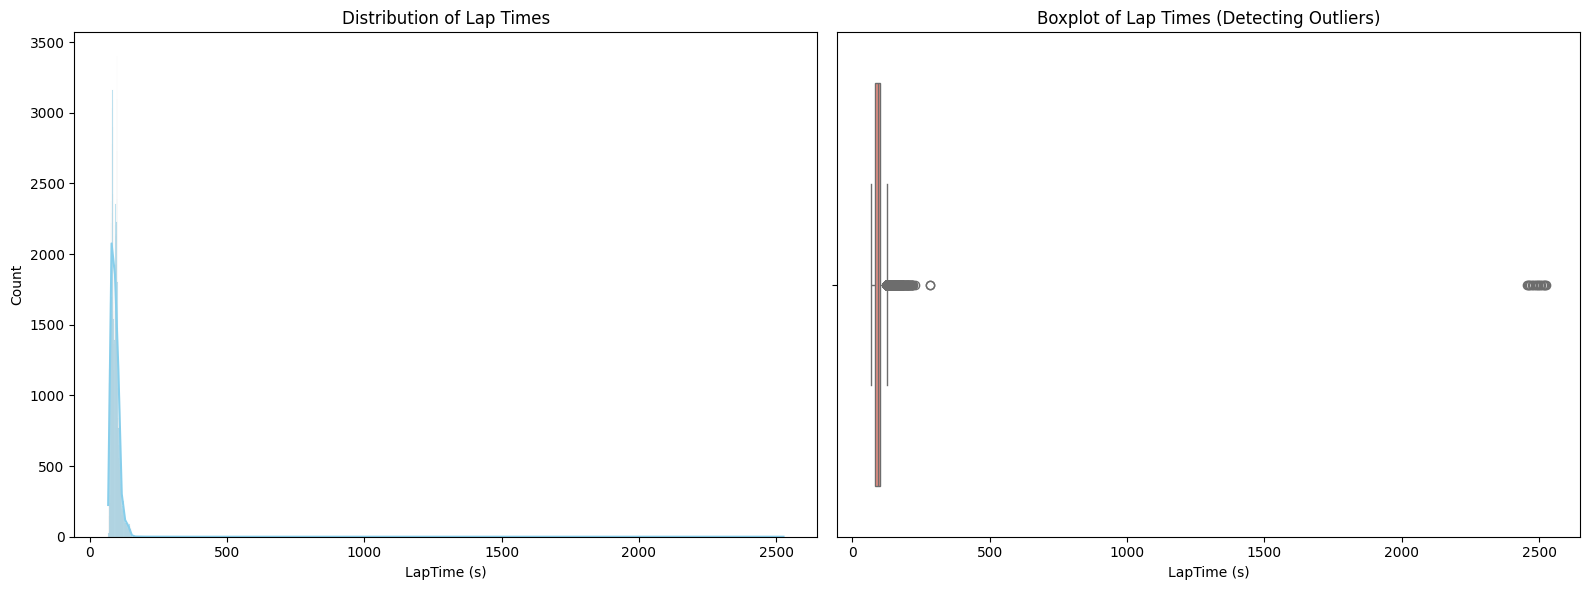

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Histogram with KDE
sns.histplot(df['LapTime (s)'], kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Distribution of Lap Times')

# Boxplot for outliers
sns.boxplot(x=df['LapTime (s)'], ax=axes[1], color='salmon')
axes[1].set_title('Boxplot of Lap Times (Detecting Outliers)')

plt.tight_layout()
plt.show()

### Removing Outliers
Based on the IQR analysis, we will now filter the dataset to exclude extreme lap time values, ensuring more robust statistical modeling.

In [31]:
# Filter the dataset using the bounds calculated in the previous cell
df_cleaned = df[(df['LapTime (s)'] >= lb) & (df['LapTime (s)'] <= ub)].copy()

print(f"Original dataset size: {len(df)}")
print(f"Cleaned dataset size: {len(df_cleaned)}")
print(f"Rows removed: {len(df) - len(df_cleaned)}")

# Quick check on the new distribution
display(df_cleaned['LapTime (s)'].describe())

Original dataset size: 101305
Cleaned dataset size: 98379
Rows removed: 2926


,LapTime (s)
count,98379.000000
mean,90.884022
std,11.681455
min,67.012000
25%,81.847000
50%,90.385000
75%,98.779000
max,125.354000


### Correlation Analysis on Cleaned Data
We recalculate the correlations to see how the removal of extreme lap time outliers (often caused by pits or incidents) affects the linear relationships between racing metrics.

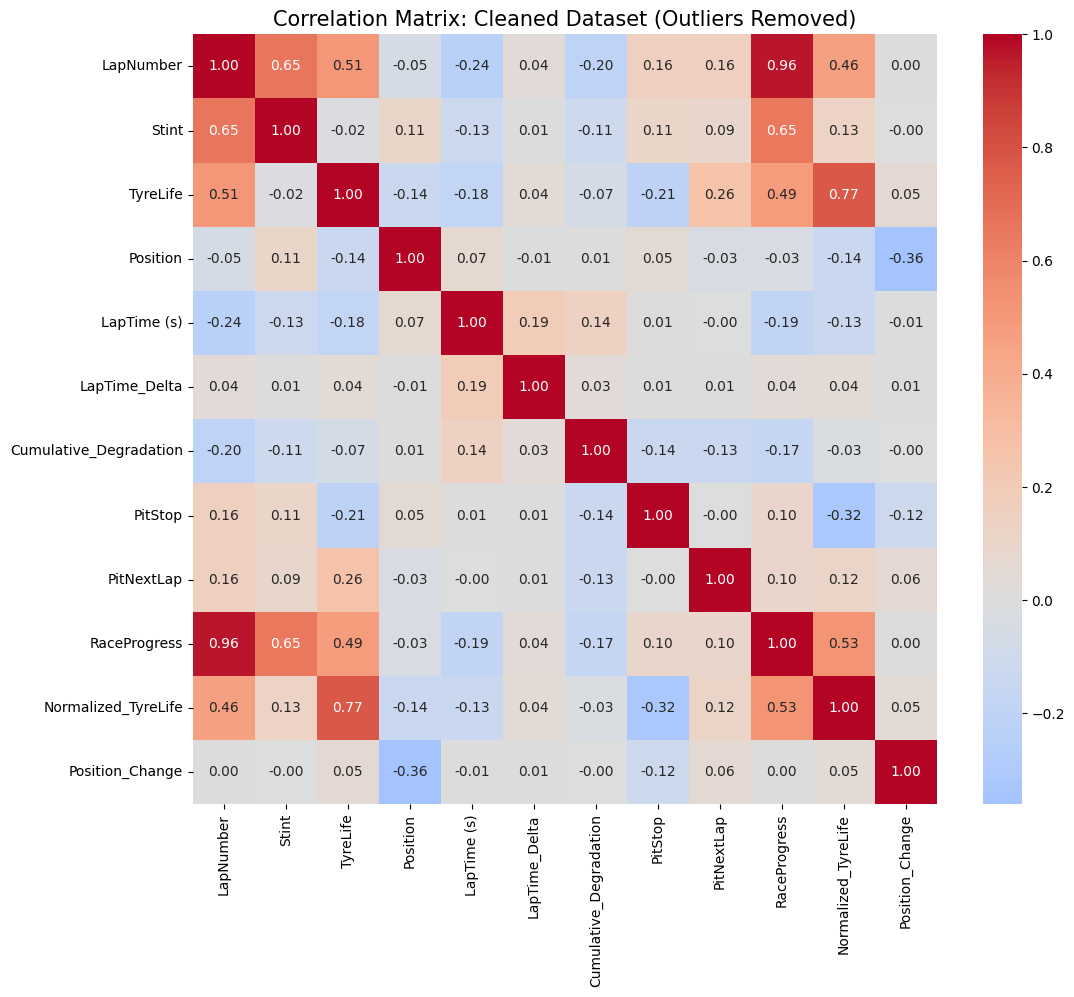

Correlations with LapTime (s) in Cleaned Data:


,LapTime (s)
LapTime (s),1.000000
LapTime_Delta,0.194674
Cumulative_Degradation,0.140513
Position,0.067099
PitStop,0.012109
PitNextLap,-0.002200
Position_Change,-0.009263
Stint,-0.129319
Normalized_TyreLife,-0.132903
TyreLife,-0.182496


In [32]:
# Calculate correlation matrix for the cleaned dataframe
cleaned_correlation_matrix = df_cleaned.select_dtypes(include=['number']).corr()

# Visualize with a heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(cleaned_correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Matrix: Cleaned Dataset (Outliers Removed)', fontsize=15)
plt.show()

# Display the top correlations for LapTime (s) specifically
print("Correlations with LapTime (s) in Cleaned Data:")
display(cleaned_correlation_matrix['LapTime (s)'].sort_values(ascending=False).to_frame())

### Predictive Modeling: Pit Stop Prediction
In this section, we build a model to predict `PitNextLap` (a binary indicator). We will use the cleaned dataset to ensure the model isn't skewed by extreme outliers.

In [33]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder

# Prepare features and target
# We'll include categorical data by encoding it
model_df = df_cleaned.copy()
le = LabelEncoder()
model_df['Compound_Encoded'] = le.fit_transform(model_df['Compound'])
model_df['Race_Encoded'] = le.fit_transform(model_df['Race'])

features = ['LapNumber', 'Stint', 'TyreLife', 'Position', 'Compound_Encoded', 'Race_Encoded', 'Cumulative_Degradation', 'RaceProgress']
X = model_df[features]
y = model_df['PitNextLap']

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Initialize and train Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf_model.fit(X_train, y_train)

# Predictions
y_pred = rf_model.predict(X_test)

print("Model Evaluation Summary:")
print(classification_report(y_test, y_pred))

Model Evaluation Summary:
              precision    recall  f1-score   support

           0       0.94      0.98      0.96     14612
           1       0.94      0.81      0.87      5064

    accuracy                           0.94     19676
   macro avg       0.94      0.90      0.91     19676
weighted avg       0.94      0.94      0.94     19676



/tmp/ipykernel_863/3364549174.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances[indices], y=[features[i] for i in indices], palette='magma')


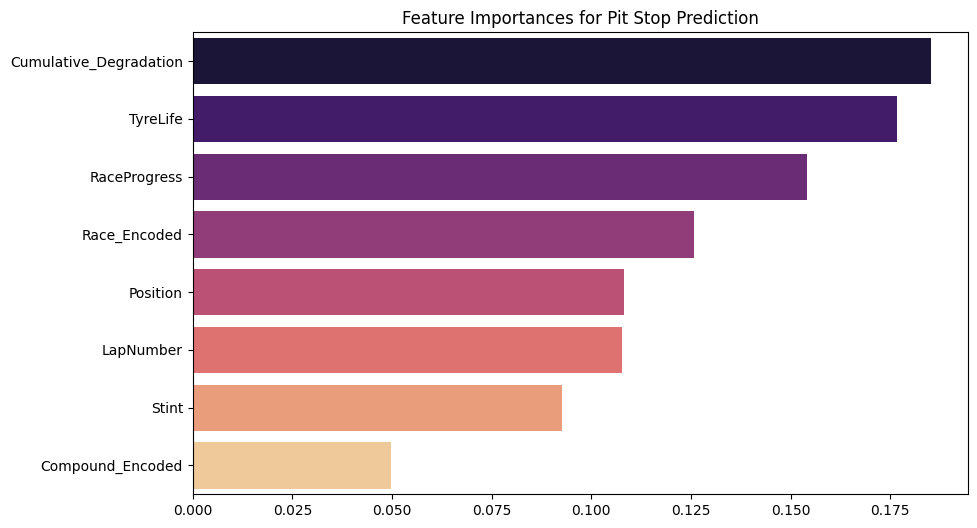

In [34]:
# Feature Importance
importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 6))
plt.title("Feature Importances for Pit Stop Prediction")
sns.barplot(x=importances[indices], y=[features[i] for i in indices], palette='magma')
plt.show()

### Deep Dive: Pit Stop Strategy for Max Verstappen (VER)
In this section, we analyze the specific behavior and strategy patterns for Max Verstappen using the cleaned dataset.

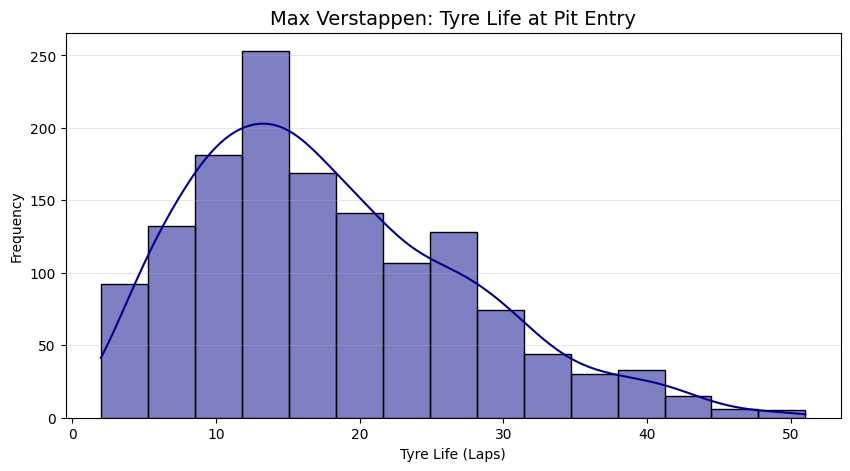

VER Average Tyre Life before pitting: 17.91 laps


In [35]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter data for Verstappen
ver_df = df_cleaned[df_cleaned['Driver'] == 'VER'].copy()

# Analyze distribution of TyreLife at the point of pitting
ver_pits = ver_df[ver_df['PitNextLap'] == 1]

plt.figure(figsize=(10, 5))
sns.histplot(ver_pits['TyreLife'], bins=15, kde=True, color='darkblue')
plt.title('Max Verstappen: Tyre Life at Pit Entry', fontsize=14)
plt.xlabel('Tyre Life (Laps)')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.3)
plt.show()

print(f"VER Average Tyre Life before pitting: {ver_pits['TyreLife'].mean():.2f} laps")

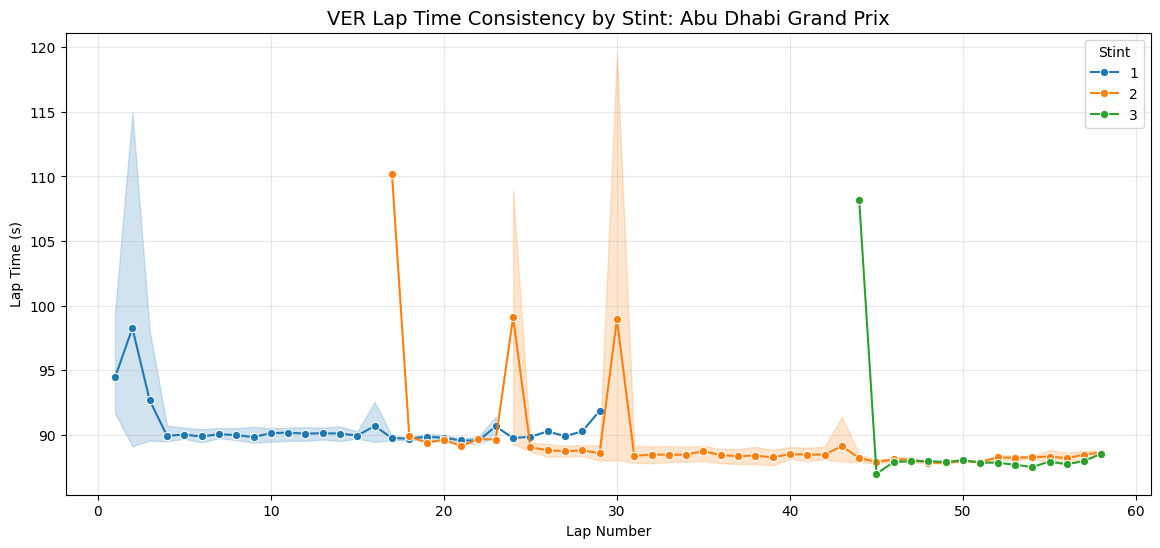

In [36]:
# Visualize Lap Time consistency across different stints for a specific race
sample_ver_race = ver_df['Race'].iloc[0]
ver_race_data = ver_df[ver_df['Race'] == sample_ver_race]

plt.figure(figsize=(14, 6))
sns.lineplot(data=ver_race_data, x='LapNumber', y='LapTime (s)', hue='Stint', palette='tab10', marker='o')
plt.title(f'VER Lap Time Consistency by Stint: {sample_ver_race}', fontsize=14)
plt.xlabel('Lap Number')
plt.ylabel('Lap Time (s)')
plt.grid(True, alpha=0.3)
plt.show()